# House price model

This notebook documents the training work. Download `house_prices.csv` from the Kaggle dataset named in the README and place it in `data/` before running.

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))
from train_house_price_model import DATA_PATH, clean, make_pipeline, NUMERIC, CATEGORICAL
import pandas as pd
df_raw = pd.read_csv(DATA_PATH)
df_raw.shape, df_raw.columns.tolist()

((187531, 21),
 ['Index',
  'Title',
  'Description',
  'Amount(in rupees)',
  'Price (in rupees)',
  'location',
  'Carpet Area',
  'Status',
  'Floor',
  'Transaction',
  'Furnishing',
  'facing',
  'overlooking',
  'Society',
  'Bathroom',
  'Balcony',
  'Car Parking',
  'Ownership',
  'Super Area',
  'Dimensions',
  'Plot Area'])

## 1. Load and inspect
The raw data is checked before assumptions are made. Price is text and several listing fields have missing values.

In [2]:
df_raw.info()
df_raw.isna().mean().sort_values(ascending=False).head(12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
dtype: float64

## 2. Clean and engineer features
Prices are converted from Lac/Cr to rupees, areas are normalised to sqft, and uncommon locations are grouped as `other`. Listings outside the 1st-99th price-per-sqft percentile are removed.

In [3]:
df = clean(df_raw)
df.shape
df[["price_clean", "carpet_area_sqft", "floor_num", "bathroom", "balcony", "location_grouped"]].head()

,price_clean,carpet_area_sqft,floor_num,bathroom,balcony,location_grouped
0,4200000.0,500.0,10.0,1.0,2.0,thane
1,9800000.0,473.0,3.0,2.0,NaN,thane
2,14000000.0,779.0,10.0,2.0,NaN,thane
3,2500000.0,530.0,1.0,1.0,1.0,thane
4,16000000.0,635.0,20.0,2.0,NaN,thane


## 3. Exploratory data analysis
The following four charts inspect skew in price, its relationship with area, location differences, and furnishing differences.

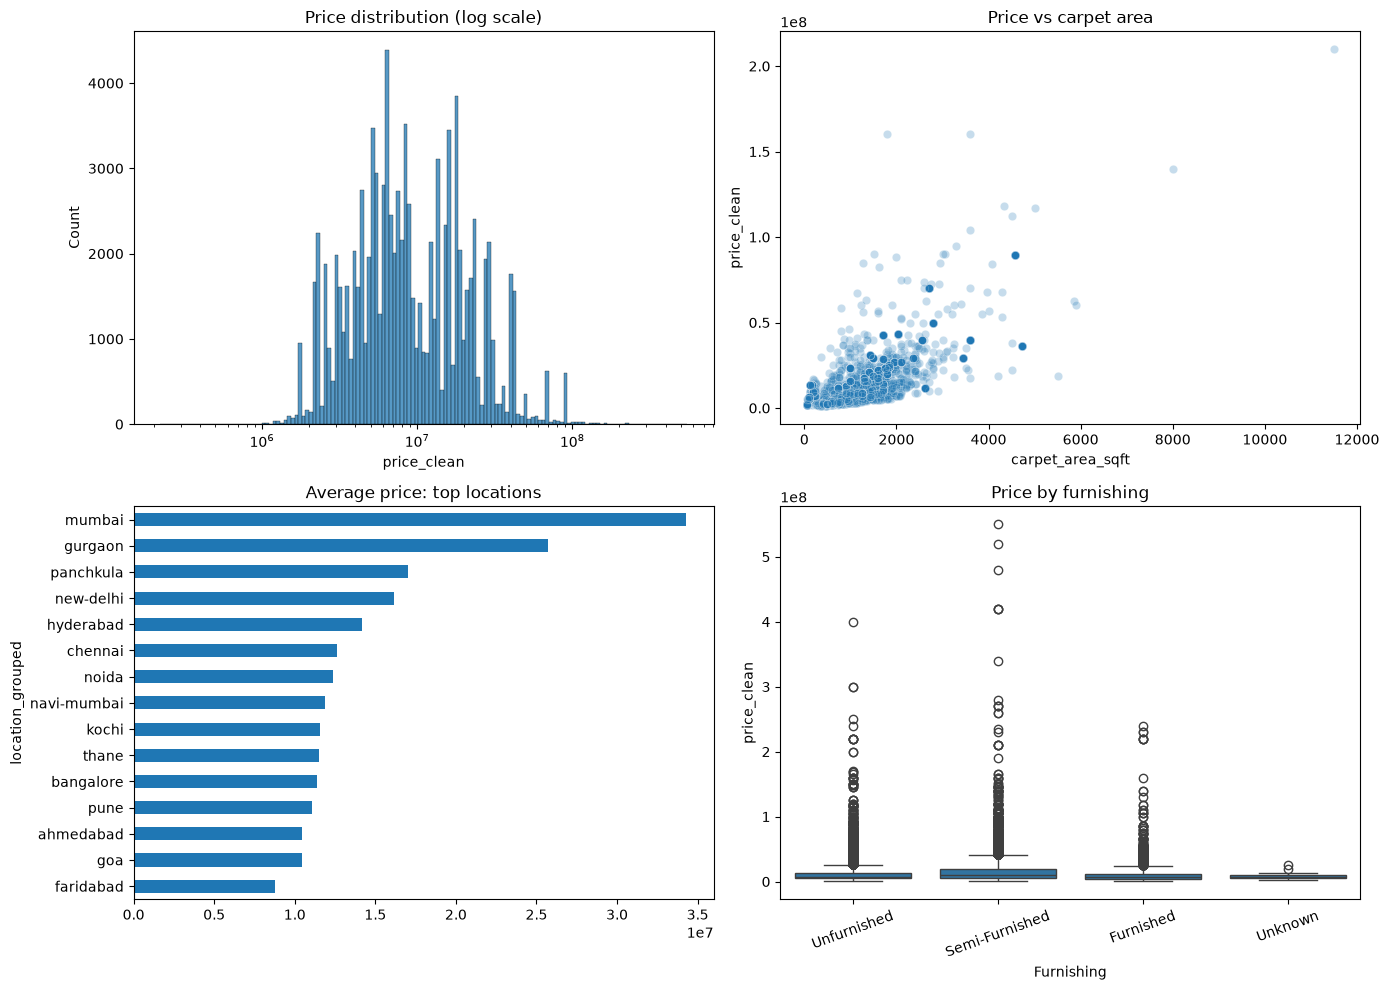

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df.price_clean, log_scale=True, ax=axes[0,0]); axes[0,0].set_title("Price distribution (log scale)")
sns.scatterplot(data=df.sample(min(5000, len(df)), random_state=42), x="carpet_area_sqft", y="price_clean", alpha=.25, ax=axes[0,1]); axes[0,1].set_title("Price vs carpet area")
top = df.groupby("location_grouped").price_clean.mean().nlargest(15).sort_values(); top.plot.barh(ax=axes[1,0], title="Average price: top locations")
sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[1,1]); axes[1,1].tick_params(axis="x", rotation=20); axes[1,1].set_title("Price by furnishing")
plt.tight_layout()

## EDA observations

- The price distribution is strongly right-skewed, so a smaller number of expensive properties pull the average upward. This is why viewing the target on a log scale is useful.
- Carpet area has a positive relationship with price, although properties with similar areas can still have very different prices because location and property details matter.
- Average prices vary noticeably by location, which confirms that location should be included as a model feature.
- Furnishing status also affects prices, but the box plots overlap. It is useful, but not enough on its own to predict price accurately.

## 4. Train, evaluate, and export
Ridge is a quick baseline. Random forest is selected if it has lower test MAE and stronger R²; the entire preprocessing pipeline is saved with the model.

In [5]:
from train_house_price_model import main
main()

ridge {'MAE': 4540533.55, 'RMSE': 7501115.29, 'R2': 0.7206}
random_forest {'MAE': 1061248.01, 'RMSE': 3997193.53, 'R2': 0.9207}


## Model comparison and conclusion

| Model | MAE | RMSE | R² |
| --- | ---: | ---: | ---: |
| Ridge Regression | 4,540,533.55 | 7,501,115.29 | 0.7206 |
| Random Forest | 1,061,248.01 | 3,997,193.53 | 0.9207 |

Random Forest was selected as the final model. It has a much lower MAE and RMSE than Ridge Regression, and its R² score of 0.9207 shows that it explains most of the variation in the test-set prices. The model is saved as a full pipeline, so the same cleaning and encoding steps are used by the FastAPI backend.